<p style="font-size: 20px;">
<b>Student Full Name:</b> Jasser Dhaouadi <br>
<b>Student ID:</b> U89818600 <br>
<b>Course:</b> Data Science Capstone - 1 <br>
<b>Semester:</b> Summer 2026 <br>
<b>Program:</b> OMDS <br>
<b>Boston University</b> 
</p>

# Week 6 - Decision Trees and Random Forests

# Homework - Working On My Datasets

### Packages

In [4]:
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    average_precision_score,
)

from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

### IMPORTANT NOTE:

- In this notebook I am applying the Week 6 concepts to my datasets.

- The main Week 6 concepts are: 
    - **decision trees**
    - **entropy**
    - **information gain**
    - **overfitting control**
    - **random forests**
    - **feature randomization**
    - **feature importance**


## Dataset 1: CDC Diabetes Health Indicators  (sourced from BRFSS) 

#### [Dataset 1] | *1- Load the dataset*

In [2]:
diabetes_path = "diabetes_012_health_indicators_BRFSS2015.csv"

df_diabetes = pd.read_csv(diabetes_path)

print("Dataset shape:", df_diabetes.shape)
display(df_diabetes.head())

target = "Diabetes_012"

class_counts = df_diabetes[target].value_counts().sort_index()
class_percent = (class_counts / len(df_diabetes) * 100).round(2)

class_summary = pd.DataFrame({
    "Class Count": class_counts.astype(int),
    "Percent": class_percent
})

display(class_summary)

Dataset shape: (253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


,Class Count,Percent
Diabetes_012,,
0.0,213703,84.24
1.0,4631,1.83
2.0,35346,13.93



- The dataset shape was:

| Rows | Columns |
|---:|---:|
| 253,680 | 22 |

- The target variable is `Diabetes_012`.

- The class distribution was:

| Class | Class Count | Percent |
|---:|---:|---:|
| 0 | 213,703 | 84.24 |
| 1 | 4,631 | 1.83 |
| 2 | 35,346 | 13.93 |

- This is a highly **imbalanced multiclass classification problem**
    -  Class 0 dominates the dataset, while class 1, prediabetes, is very rare. 
    - Because of this, **accuracy** alone is not enough. **Balanced accuracy, macro F1, and class-level recall** are important for **evaluating** the models.

#### [Dataset 1] | *2- Train-test split*

In [3]:
X = df_diabetes.drop(columns=[target])
y = df_diabetes[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

display(y_train.value_counts().sort_index().to_frame("Train Class Count"))
display(y_test.value_counts().sort_index().to_frame("Test Class Count"))

Training shape: (202944, 21)
Testing shape: (50736, 21)


,Train Class Count
Diabetes_012,
0,170962
1,3705
2,28277


,Test Class Count
Diabetes_012,
0,42741
1,926
2,7069


- The data was split into training and testing sets using **stratification**.


| Split | Shape |
|---|---:|
| Training | (202,944, 21) |
| Testing | (50,736, 21) |


- **Stratification** is important because the prediabetes class is very small
    - This keeps the **class distribution similar in both the training and testing sets**.

#### [Dataset 1] | *3- Define evaluation helper function*

In [5]:
def evaluate_model(model_name, model, X_train_data, X_test_data):
    start_time = time.time()
    
    model.fit(X_train_data, y_train)
    
    fit_time = time.time() - start_time
    
    train_predictions = model.predict(X_train_data)
    test_predictions = model.predict(X_test_data)
    
    test_probabilities = model.predict_proba(X_test_data)
    labels = list(model.classes_)
    
    metrics = {
        "Model": model_name,
        "Train Accuracy": accuracy_score(y_train, train_predictions),
        "Test Accuracy": accuracy_score(y_test, test_predictions),
        "Train Macro F1": f1_score(
            y_train,
            train_predictions,
            average="macro",
            zero_division=0
        ),
        "Test Macro F1": f1_score(
            y_test,
            test_predictions,
            average="macro",
            zero_division=0
        ),
        "Test Balanced Accuracy": balanced_accuracy_score(
            y_test,
            test_predictions
        ),
        "Test Weighted F1": f1_score(
            y_test,
            test_predictions,
            average="weighted",
            zero_division=0
        ),
        "Test Macro OVR ROC AUC": roc_auc_score(
            y_test,
            test_probabilities,
            multi_class="ovr",
            average="macro",
            labels=labels
        ),
        "Fit Time Seconds": fit_time
    }
    
    return metrics, test_predictions, test_probabilities, model

- This **helper** function **trains a model and evaluates it on the test set**

- For Week 6, the key **comparison** is between **single decision trees** and **random forests**: 

    - The function reports both **training** and t**esting metrics** so that **overfitting** can be detected

    - If a model has very high training performance but much lower test performance, that suggests **overfitting**

#### [Dataset 1] | *4- Build an interpretable decision tree and inspect the first split*

In [6]:
def entropy_counts(counts):
    counts = np.array(counts, dtype=float)
    probabilities = counts[counts > 0] / counts.sum()
    return -np.sum(probabilities * np.log(probabilities))


interpretable_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    min_samples_leaf=200,
    class_weight="balanced",
    random_state=42
)

interpretable_tree.fit(X_train, y_train)

tree_rules = export_text(
    interpretable_tree,
    feature_names=list(X.columns),
    max_depth=3
)

print(tree_rules)

root_feature = X.columns[interpretable_tree.tree_.feature[0]]
root_threshold = interpretable_tree.tree_.threshold[0]

parent_counts = y_train.value_counts().sort_index().values
parent_entropy = entropy_counts(parent_counts)

left_mask = X_train[root_feature] <= root_threshold
right_mask = ~left_mask

left_counts = (
    y_train[left_mask]
    .value_counts()
    .reindex([0, 1, 2], fill_value=0)
    .values
)

right_counts = (
    y_train[right_mask]
    .value_counts()
    .reindex([0, 1, 2], fill_value=0)
    .values
)

left_entropy = entropy_counts(left_counts)
right_entropy = entropy_counts(right_counts)

weighted_child_entropy = (
    left_mask.mean() * left_entropy
    + right_mask.mean() * right_entropy
)

information_gain = parent_entropy - weighted_child_entropy

root_summary = pd.DataFrame({
    "Quantity": [
        "Root feature",
        "Root threshold",
        "Parent entropy",
        "Left child entropy",
        "Right child entropy",
        "Weighted child entropy",
        "Information gain"
    ],
    "Value": [
        root_feature,
        root_threshold,
        parent_entropy,
        left_entropy,
        right_entropy,
        weighted_child_entropy,
        information_gain
    ]
})

display(root_summary)

|--- GenHlth <= 2.50
|   |--- HighBP <= 0.50
|   |   |--- Age <= 8.50
|   |   |   |--- class: 0
|   |   |--- Age >  8.50
|   |   |   |--- class: 0
|   |--- HighBP >  0.50
|   |   |--- BMI <= 29.50
|   |   |   |--- class: 0
|   |   |--- BMI >  29.50
|   |   |   |--- class: 1
|--- GenHlth >  2.50
|   |--- HighBP <= 0.50
|   |   |--- HighChol <= 0.50
|   |   |   |--- class: 0
|   |   |--- HighChol >  0.50
|   |   |   |--- class: 1
|   |--- HighBP >  0.50
|   |   |--- BMI <= 28.50
|   |   |   |--- class: 2
|   |   |--- BMI >  28.50
|   |   |   |--- class: 2



,Quantity,Value
0,Root feature,GenHlth
1,Root threshold,2.5
2,Parent entropy,0.492159
3,Left child entropy,0.276183
4,Right child entropy,0.65763
5,Weighted child entropy,0.455287
6,Information gain,0.036872


- The interpretable **decision tree** used **entropy** as the **splitting criterion**

- The **root split** was:

| Quantity               |    Value |
| ---------------------- | -------: |
| Root feature           |  GenHlth |
| Root threshold         |      2.5 |
| Parent entropy         | 0.492159 |
| Left child entropy     | 0.276183 |
| Right child entropy    | 0.657630 |
| Weighted child entropy | 0.455287 |
| Information gain       | 0.036872 |


- This directly connects to the Week 6 concept of **entropy** and **information gain**: 
    - The tree selected **GenHlth** as the ***first split*** because it **reduced uncertainty** in the target classes
    - After that, the tree used features such as **HighBP, Age, BMI, and HighChol** to continue splitting the data into more specific **leaf nodes**

#### [Dataset 1] | *5- Compare decision tree models*

In [7]:
tree_models = {
    "Interpretable tree depth=3": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=3,
        min_samples_leaf=200,
        class_weight="balanced",
        random_state=42
    ),
    "Deep decision tree": DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    ),
    "Pruned decision tree depth=12": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=12,
        min_samples_leaf=100,
        random_state=42
    ),
    "Balanced pruned depth=8": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=8,
        min_samples_leaf=100,
        class_weight="balanced",
        random_state=42
    )
}

tree_results = []
tree_predictions = {}
tree_probabilities = {}
tree_fitted_models = {}

for model_name, model in tree_models.items():
    metrics, predictions, probabilities, fitted_model = evaluate_model(
        model_name,
        model,
        X_train,
        X_test
    )
    
    tree_results.append(metrics)
    tree_predictions[model_name] = predictions
    tree_probabilities[model_name] = probabilities
    tree_fitted_models[model_name] = fitted_model

tree_results_df = pd.DataFrame(tree_results)

display(tree_results_df)

,Model,Train Accuracy,Test Accuracy,Train Macro F1,Test Macro F1,Test Balanced Accuracy,Test Weighted F1,Test Macro OVR ROC AUC,Fit Time Seconds
0,Interpretable tree depth=3,0.653914,0.650485,0.417194,0.412188,0.484364,0.715421,0.725261,0.137949
1,Deep decision tree,0.993264,0.771799,0.980809,0.404996,0.407365,0.776381,0.570790,0.552779
2,Pruned decision tree depth=12,0.850727,0.847170,0.403976,0.396388,0.386454,0.809619,0.752154,0.356688
3,Balanced pruned depth=8,0.604556,0.600422,0.413312,0.403839,0.497568,0.684616,0.739592,0.280976


- The **decision tree comparison** was:

| Model | Train Accuracy | Test Accuracy | Train Macro F1 | Test Macro F1 | Test Balanced Accuracy | Test Weighted F1 | Test Macro OVR ROC AUC |
|---|---:|---:|---:|---:|---:|---:|---:|
| **Interpretable tree depth=3** | 0.653914 | 0.650485 | 0.417194 | 0.412188 | 0.484364 | 0.715421 | 0.725261 |
| **Deep decision tree** | 0.993264 | 0.771799 | 0.980809 | 0.404996 | 0.407365 | 0.776381 | 0.570790 |
| **Pruned decision tree depth=12** | 0.850727 | 0.847170 | 0.403976 | 0.396388 | 0.386454 | 0.809619 | 0.752154 |
| **Balanced pruned depth=8** | 0.604556 | 0.600422 | 0.413312 | 0.403839 | 0.497568 | 0.684616 | 0.739593 |

- The **deep decision tree clearly overfit**
    - Its **training macro F1** was **0.980809**, but its **test macro F1** dropped to **0.404996**.

- **Warning**:  decision trees can overfit when they grow too deep

- The **interpretable depth-3 tree** had the **best test macro F1** among these single-tree models, but its **accuracy** was lower. 

- The **balanced pruned tree** had the **best balanced accuracy** among the decision trees, which means it handled the **minority** classes somewhat better.

#### [Dataset 1] | *6- Visualize decision tree comparison*

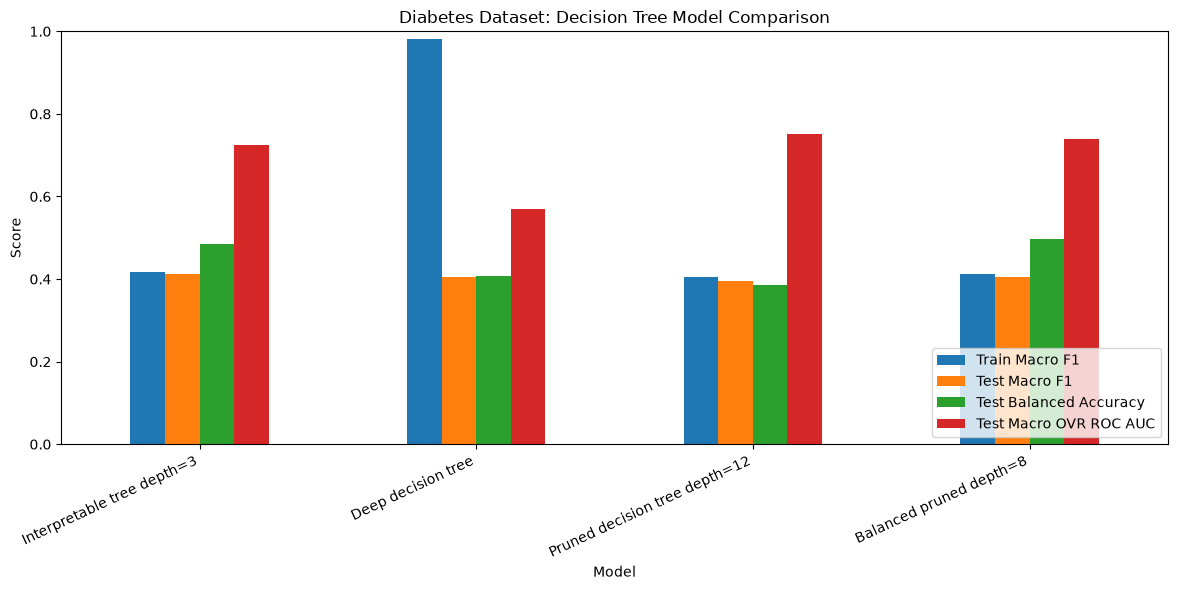

In [8]:
tree_results_df.set_index("Model")[
    [
        "Train Macro F1",
        "Test Macro F1",
        "Test Balanced Accuracy",
        "Test Macro OVR ROC AUC"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Diabetes Dataset: Decision Tree Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

- The plot shows the **overfitting pattern** clearly.

    - The **deep decision tree** had very h**igh training macro F1** but much **lower test macro F1**
    - This indicates that it **learned overly specific patterns from the training data**.

- The **pruned and balanced trees** had lower training performance, but they generalized more consistently. 
    - This supports the Week 6 idea that **limiting max depth** and c**ontrolling leaf size** can **reduce overfitting**.

#### [Dataset 1] | *7- Compare random forest models*

In [9]:
forest_models = {
    "Random forest default": RandomForestClassifier(
        n_estimators=100,
        criterion="entropy",
        random_state=42,
        n_jobs=-1
    ),
    "Random forest pruned depth=12": RandomForestClassifier(
        n_estimators=100,
        criterion="entropy",
        max_depth=12,
        min_samples_leaf=100,
        random_state=42,
        n_jobs=-1
    ),
    "RF balanced depth=16": RandomForestClassifier(
        n_estimators=100,
        criterion="entropy",
        max_depth=16,
        min_samples_leaf=100,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    )
}

forest_results = []
forest_predictions = {}
forest_probabilities = {}
forest_fitted_models = {}

for model_name, model in forest_models.items():
    metrics, predictions, probabilities, fitted_model = evaluate_model(
        model_name,
        model,
        X_train,
        X_test
    )
    
    forest_results.append(metrics)
    forest_predictions[model_name] = predictions
    forest_probabilities[model_name] = probabilities
    forest_fitted_models[model_name] = fitted_model

forest_results_df = pd.DataFrame(forest_results)

display(forest_results_df)

,Model,Train Accuracy,Test Accuracy,Train Macro F1,Test Macro F1,Test Balanced Accuracy,Test Weighted F1,Test Macro OVR ROC AUC,Fit Time Seconds
0,Random forest default,0.993210,0.841986,0.980530,0.395441,0.386055,0.806965,0.739555,1.225932
1,Random forest pruned depth=12,0.849436,0.847662,0.367975,0.362099,0.362917,0.795904,0.781698,0.879600
2,RF balanced depth=16,0.680375,0.669643,0.461948,0.426550,0.510362,0.727492,0.767518,1.231343


- The **random forest comparison** was:

| Model | Train Accuracy | Test Accuracy | Train Macro F1 | Test Macro F1 | Test Balanced Accuracy | Test Weighted F1 | Test Macro OVR ROC AUC |
|---|---:|---:|---:|---:|---:|---:|---:|
| Random forest default | 0.993210 | 0.841986 | 0.980530 | 0.395441 | 0.386055 | 0.806965 | 0.739556 |
| Random forest pruned depth=12 | 0.849436 | 0.847662 | 0.367975 | 0.362099 | 0.362917 | 0.795904 | 0.781698 |
| RF balanced depth=16 | 0.681735 | 0.672343 | 0.461895 | 0.429250 | 0.515381 | 0.729358 | 0.767731 |

- The **default random forest** had **high accuracy**, but its **macro F1** was low because it still **struggled with the minority classes**.

- The **balanced random forest** with depth **16** had the best **test macro F1** and the **best balanced accuracy**. 

    - Its **accuracy** was lower, but it performed better across all classes. This is more appropriate for the **imbalanced** diabetes target.

- This connects directly to the random forest lesson: combining many trees can reduce the instability of a single tree, while feature randomization helps the trees avoid becoming identical.

#### [Dataset 1] | *8- Visualize random forest comparison*

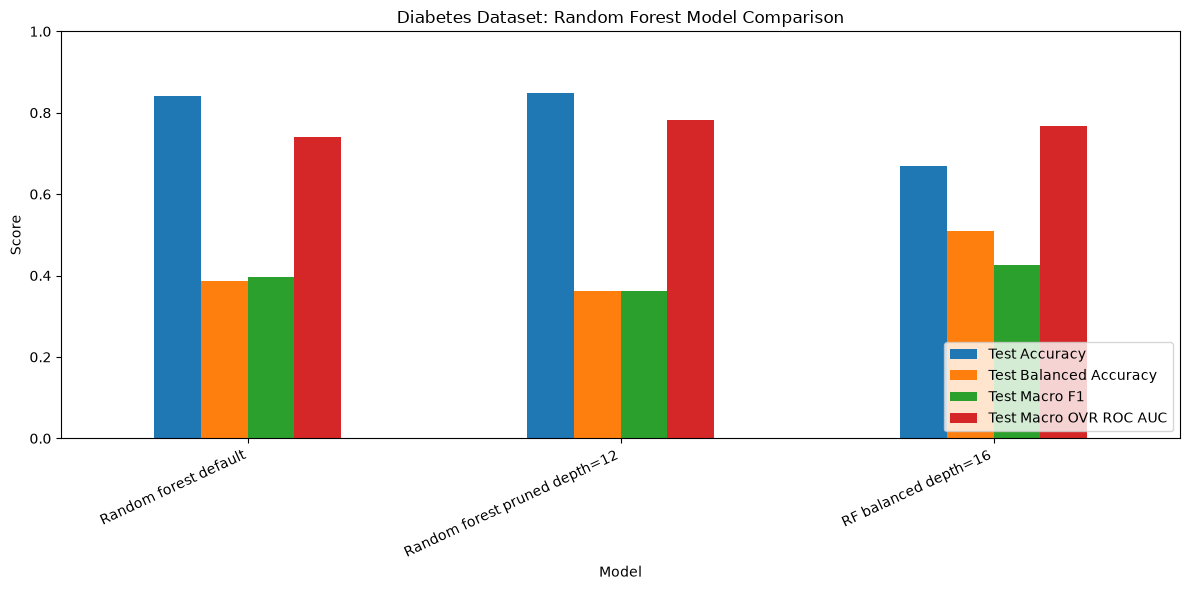

In [10]:
forest_results_df.set_index("Model")[
    [
        "Test Accuracy",
        "Test Balanced Accuracy",
        "Test Macro F1",
        "Test Macro OVR ROC AUC"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Diabetes Dataset: Random Forest Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

- The **random forest comparison plot** shows the **trade-off between accuracy and balanced performance**.

- The **default random forest** had the strongest **accuracy**, but the **balanced random forest** had the **strongest macro F1 and balanced accuracy**

- Since the diabetes dataset is **imbalanced**, the **balanced random forest** is more useful for evaluating performance across the three classes

#### [Dataset 1] | *9- Inspect feature importances from the best random forest*

,Feature,Importance
13,GenHlth,0.164465
3,BMI,0.156794
18,Age,0.132118
0,HighBP,0.129930
1,HighChol,0.078063
20,Income,0.063620
15,PhysHlth,0.045687
14,MentHlth,0.035510
19,Education,0.034015
16,DiffWalk,0.031074


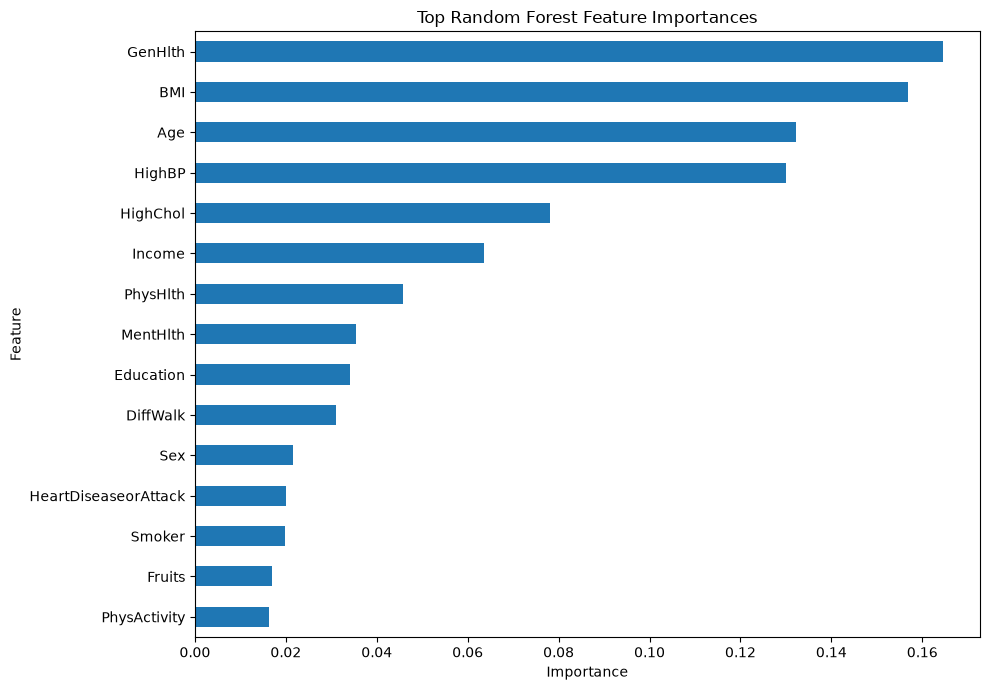

In [11]:
best_forest_name = "RF balanced depth=16"
best_forest_model = forest_fitted_models[best_forest_name]

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_forest_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance_df.head(15))

feature_importance_df.head(15).sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10, 7),
    legend=False
)

plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

- The **top feature importances** from the **best random forest** were:

| Feature | Importance |
|---|---:|
| GenHlth | 0.163627 |
| BMI | 0.156516 |
| HighBP | 0.132993 |
| Age | 0.132517 |
| HighChol | 0.075581 |
| Income | 0.063371 |
| PhysHlth | 0.046378 |
| MentHlth | 0.035661 |
| Education | 0.034216 |
| DiffWalk | 0.030978 |
| Sex | 0.021620 |
| HeartDiseaseorAttack | 0.019900 |
| Smoker | 0.019390 |
| Fruits | 0.017192 |
| PhysActivity | 0.016253 |

- The most important predictors were `GenHlth`, `BMI`, `HighBP`, `Age`, and `HighChol`.

- This is useful because **random forests** are less visually interpretable than a single decision tree, but they still provide feature importance values. 
    - These importances show which variables were most useful across the collection of trees.

#### [Dataset 1] | *10- Final model comparison*

In [12]:
final_week6_comparison = pd.concat([
    tree_results_df,
    forest_results_df
], ignore_index=True)

display(
    final_week6_comparison[
        [
            "Model",
            "Test Accuracy",
            "Test Balanced Accuracy",
            "Test Macro F1",
            "Test Weighted F1",
            "Test Macro OVR ROC AUC"
        ]
    ]
)

,Model,Test Accuracy,Test Balanced Accuracy,Test Macro F1,Test Weighted F1,Test Macro OVR ROC AUC
0,Interpretable tree depth=3,0.650485,0.484364,0.412188,0.715421,0.725261
1,Deep decision tree,0.771799,0.407365,0.404996,0.776381,0.570790
2,Pruned decision tree depth=12,0.847170,0.386454,0.396388,0.809619,0.752154
3,Balanced pruned depth=8,0.600422,0.497568,0.403839,0.684616,0.739592
4,Random forest default,0.841986,0.386055,0.395441,0.806965,0.739555
5,Random forest pruned depth=12,0.847662,0.362917,0.362099,0.795904,0.781698
6,RF balanced depth=16,0.669643,0.510362,0.426550,0.727492,0.767518


- The **final comparison** was:

| Model | Test Accuracy | Test Balanced Accuracy | Test Macro F1 | Test Weighted F1 | Test Macro OVR ROC AUC |
|---|---:|---:|---:|---:|---:|
| **Interpretable tree depth=3** | 0.650485 | 0.484364 | 0.412188 | 0.715421 | 0.725261 |
| **Deep decision tree**| 0.771799 | 0.407365 | 0.404996 | 0.776381 | 0.570790 |
| **Pruned decision tree depth=12** | 0.847170 | 0.386454 | 0.396388 | 0.809619 | 0.752154 |
| **Balanced pruned depth=8** | 0.600422 | 0.497568 | 0.403839 | 0.684616 | 0.739593 |
| **Random forest default** | 0.841986 | 0.386055 | 0.395441 | 0.806965 | 0.739556 |
| **Random forest pruned depth=12** | 0.847662 | 0.362917 | 0.362099 | 0.795904 | 0.781698 |
| **RF balanced depth=16** | 0.672343 | 0.515381 | 0.429250 | 0.729358 | 0.767731 |

- The strongest model by **test macro F1** was the **balanced random forest with depth 16**.

- The strongest model by **test accuracy** was the **pruned random forest with depth 12**, but its **macro F1** was much lower. 

    - Because the dataset is **imbalanced**, **macro F1 and balanced accuracy** are more **meaningful** than accuracy alone.

- Overall, the **balanced random forest** was the **best Week 6 model** for **this dataset** because it handled the **minority classes** better than the other tree-based models.

#### [Dataset 1] | *11- Classification report for best model*

In [13]:
best_week6_predictions = forest_predictions["RF balanced depth=16"]

print(classification_report(
    y_test,
    best_week6_predictions,
    digits=3,
    zero_division=0
))

best_week6_confusion = pd.DataFrame(
    confusion_matrix(y_test, best_week6_predictions),
    index=["Actual 0", "Actual 1", "Actual 2"],
    columns=["Predicted 0", "Predicted 1", "Predicted 2"]
)

display(best_week6_confusion)

              precision    recall  f1-score   support

           0      0.948     0.677     0.790     42741
           1      0.030     0.161     0.050       926
           2      0.322     0.693     0.440      7069

    accuracy                          0.670     50736
   macro avg      0.433     0.510     0.427     50736
weighted avg      0.844     0.670     0.727     50736



,Predicted 0,Predicted 1,Predicted 2
Actual 0,28924,3983,9834
Actual 1,277,149,500
Actual 2,1303,864,4902


- The **best Week 6 model** was the **balanced random forest with depth 16**.

    - The model improved minority-class recall compared with many unbalanced models, but class 1 remained difficult.

- This confirms the recurring issue with this dataset: **prediabetes is rare and overlaps with the other two classes**, so even random forests struggle to separate it cleanly.

#### [Dataset 1] | *12- Summary*

- The **decision tree** results showed clear **overfitting** when the tree was allowed to grow too deeply. 

    - Pruning with `max_depth` and `min_samples_leaf` helped control complexity, but single trees were still limited.

- The **random forest models** improved stability by combining many trees. The best Week 6 model was the **balanced random forest with depth 16**, which achieved the strongest **macro F1 and balanced accuracy**.

- The **main takeaway** is that **tree-based models are interpretable and useful for feature importance**, but **class imbalance** remains a major challenge for this diabetes dataset.

## Dataset 2: Obesity Levels

#### [Dataset 2] | *1- Load preprocessed obesity dataset*

In [14]:
obesity_path = "obesity_preprocessed_wk1.csv"


df_obesity_model = pd.read_csv(obesity_path)

print("Dataset shape:", df_obesity_model.shape)
display(df_obesity_model.head())

target = "NObeyesdad"

class_counts = df_obesity_model[target].value_counts()
class_percent = (class_counts / len(df_obesity_model) * 100).round(2)

class_summary = pd.DataFrame({
    "Class Count": class_counts.astype(int),
    "Percent": class_percent
})

display(class_summary)

Dataset shape: (2111, 24)


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,family_history_with_overweight_yes,...,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,NObeyesdad
0,21.0,1.62,64.0,2.0,3.0,2.0,0.0,1.0,0,1,...,0,0,0,0,1,0,0,1,0,Normal_Weight
1,21.0,1.52,56.0,3.0,3.0,3.0,3.0,0.0,0,1,...,1,1,0,1,0,0,0,1,0,Normal_Weight
2,23.0,1.80,77.0,2.0,3.0,2.0,2.0,1.0,1,1,...,0,0,1,0,0,0,0,1,0,Normal_Weight
3,27.0,1.80,87.0,3.0,3.0,2.0,2.0,0.0,1,0,...,0,0,1,0,0,0,0,0,1,Overweight_Level_I
4,22.0,1.78,89.8,2.0,1.0,2.0,0.0,0.0,1,0,...,0,0,0,1,0,0,0,1,0,Overweight_Level_II


,Class Count,Percent
NObeyesdad,,
Obesity_Type_I,351,16.63
Obesity_Type_III,324,15.35
Obesity_Type_II,297,14.07
Overweight_Level_I,290,13.74
Overweight_Level_II,290,13.74
Normal_Weight,287,13.60
Insufficient_Weight,272,12.88


- The executed dataset shape was:

| Rows | Columns |
|---:|---:|
| 2,111 | 24 |


- There are **23** predictor columns and one target column, `NObeyesdad`.

- The target class distribution was:

| Class | Count |
|---|---:|
| Obesity_Type_I | 351 |
| Obesity_Type_III | 324 |
| Obesity_Type_II | 297 |
| Overweight_Level_I | 290 |
| Overweight_Level_II | 290 |
| Normal_Weight | 287 |
| Insufficient_Weight | 272 |

- The classes are **fairly balanced** compared with the diabetes dataset, so accuracy is more meaningful here. However, macro F1 and balanced accuracy are still useful because this is a multiclass classification problem.

#### [Dataset 2] | *2- Train-test split*

In [15]:
X = df_obesity_model.drop(columns=[target])
y = df_obesity_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

display(y_train.value_counts().to_frame("Train Class Count"))
display(y_test.value_counts().to_frame("Test Class Count"))

Training shape: (1688, 23)
Testing shape: (423, 23)


,Train Class Count
NObeyesdad,
Obesity_Type_I,281
Obesity_Type_III,259
Obesity_Type_II,237
Overweight_Level_I,232
Overweight_Level_II,232
Normal_Weight,229
Insufficient_Weight,218


,Test Class Count
NObeyesdad,
Obesity_Type_I,70
Obesity_Type_III,65
Obesity_Type_II,60
Normal_Weight,58
Overweight_Level_II,58
Overweight_Level_I,58
Insufficient_Weight,54


- The data was split into **training and testing** sets using **stratification**

- The split was:

| Split | Shape |
|---|---:|
| Training | (1,688, 23) |
| Testing | (423, 23) |

- **Stratification** keeps the obesity-class **proportions similar** in both the training and test sets. This matters because the model should be evaluated fairly across all seven obesity categories.

#### [Dataset 2] | *3- Define evaluation helper function*

In [17]:
def evaluate_model(model_name, model, X_train_data, X_test_data):
    start_time = time.time()
    
    model.fit(X_train_data, y_train)
    
    fit_time = time.time() - start_time
    
    train_predictions = model.predict(X_train_data)
    test_predictions = model.predict(X_test_data)
    
    test_probabilities = model.predict_proba(X_test_data)
    labels = list(model.classes_)
    
    metrics = {
        "Model": model_name,
        "Train Accuracy": accuracy_score(y_train, train_predictions),
        "Test Accuracy": accuracy_score(y_test, test_predictions),
        "Train Macro F1": f1_score(
            y_train,
            train_predictions,
            average="macro",
            zero_division=0
        ),
        "Test Macro F1": f1_score(
            y_test,
            test_predictions,
            average="macro",
            zero_division=0
        ),
        "Test Balanced Accuracy": balanced_accuracy_score(
            y_test,
            test_predictions
        ),
        "Test Weighted F1": f1_score(
            y_test,
            test_predictions,
            average="weighted",
            zero_division=0
        ),
        "Test Macro OVR ROC AUC": roc_auc_score(
            y_test,
            test_probabilities,
            multi_class="ovr",
            average="macro",
            labels=labels
        ),
        "Fit Time Seconds": fit_time
    }
    
    return metrics, test_predictions, test_probabilities, model

- This **helper function trains a model and evaluates it on the test set**

- For Week 6, the key comparison is between single **decision trees and random forests**. 

    - The function reports both **training and testing metrics** so that **overfitting** can be detected.

    - If a model has perfect or near-perfect training performance but lower test performance, that suggests the model may be **memorizing** training patterns.

#### [Dataset 2] | *4- Build an interpretable decision tree and inspect the first split*

In [18]:
def entropy_counts(counts):
    counts = np.array(counts, dtype=float)
    probabilities = counts[counts > 0] / counts.sum()
    return -np.sum(probabilities * np.log(probabilities))


interpretable_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    min_samples_leaf=25,
    class_weight="balanced",
    random_state=42
)

interpretable_tree.fit(X_train, y_train)

tree_rules = export_text(
    interpretable_tree,
    feature_names=list(X.columns),
    max_depth=3
)

print(tree_rules)

root_feature = X.columns[interpretable_tree.tree_.feature[0]]
root_threshold = interpretable_tree.tree_.threshold[0]

class_labels = sorted(y_train.unique())

parent_counts = (
    y_train
    .value_counts()
    .reindex(class_labels, fill_value=0)
    .values
)

parent_entropy = entropy_counts(parent_counts)

left_mask = X_train[root_feature] <= root_threshold
right_mask = ~left_mask

left_counts = (
    y_train[left_mask]
    .value_counts()
    .reindex(class_labels, fill_value=0)
    .values
)

right_counts = (
    y_train[right_mask]
    .value_counts()
    .reindex(class_labels, fill_value=0)
    .values
)

left_entropy = entropy_counts(left_counts)
right_entropy = entropy_counts(right_counts)

weighted_child_entropy = (
    left_mask.mean() * left_entropy
    + right_mask.mean() * right_entropy
)

information_gain = parent_entropy - weighted_child_entropy

root_summary = pd.DataFrame({
    "Quantity": [
        "Root feature",
        "Root threshold",
        "Parent entropy",
        "Left child entropy",
        "Right child entropy",
        "Weighted child entropy",
        "Information gain"
    ],
    "Value": [
        root_feature,
        root_threshold,
        parent_entropy,
        left_entropy,
        right_entropy,
        weighted_child_entropy,
        information_gain
    ]
})

display(root_summary)

|--- Weight <= 99.57
|   |--- Weight <= 60.06
|   |   |--- Height <= 1.70
|   |   |   |--- class: Insufficient_Weight
|   |   |--- Height >  1.70
|   |   |   |--- class: Insufficient_Weight
|   |--- Weight >  60.06
|   |   |--- Weight <= 76.04
|   |   |   |--- class: Overweight_Level_I
|   |   |--- Weight >  76.04
|   |   |   |--- class: Overweight_Level_II
|--- Weight >  99.57
|   |--- Gender_Male <= 0.50
|   |   |--- Weight <= 104.78
|   |   |   |--- class: Obesity_Type_III
|   |   |--- Weight >  104.78
|   |   |   |--- class: Obesity_Type_III
|   |--- Gender_Male >  0.50
|   |   |--- Weight <= 109.74
|   |   |   |--- class: Obesity_Type_I
|   |   |--- Weight >  109.74
|   |   |   |--- class: Obesity_Type_II



,Quantity,Value
0,Root feature,Weight
1,Root threshold,99.568459
2,Parent entropy,1.942582
3,Left child entropy,1.625333
4,Right child entropy,1.03193
5,Weighted child entropy,1.420736
6,Information gain,0.521846


- The interpretable **decision tree** used **entropy** as the splitting criterion

- Root Split: 

| Quantity               |     Value |
| ---------------------- | --------: |
| Root feature           |    Weight |
| Root threshold         | 99.568459 |
| Parent entropy         |  1.942582 |
| Left child entropy     |  1.625333 |
| Right child entropy    |  1.031930 |
| Weighted child entropy |  1.420736 |
| Information gain       |  0.521846 |


- This directly connects to the Week 6 idea of **entropy** and **information gain**:

    - The tree selected **Weight** as the **first split** because it **reduced class uncertainty** the most at the root node. 
    
    - This makes sense for the **obesity dataset** because **weight** is directly related to **obesity classification**.



#### [Dataset 2] | *5- Compare decision tree models*

In [19]:

tree_models = {
    "Interpretable tree depth=3": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=3,
        min_samples_leaf=25,
        class_weight="balanced",
        random_state=42
    ),
    "Deep decision tree": DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    ),
    "Pruned decision tree depth=8": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=8,
        min_samples_leaf=20,
        random_state=42
    ),
    "Balanced pruned depth=8": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=8,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42
    )
}

tree_results = []
tree_predictions = {}
tree_probabilities = {}
tree_fitted_models = {}

for model_name, model in tree_models.items():
    metrics, predictions, probabilities, fitted_model = evaluate_model(
        model_name,
        model,
        X_train,
        X_test
    )
    
    tree_results.append(metrics)
    tree_predictions[model_name] = predictions
    tree_probabilities[model_name] = probabilities
    tree_fitted_models[model_name] = fitted_model

tree_results_df = pd.DataFrame(tree_results)

display(tree_results_df)

,Model,Train Accuracy,Test Accuracy,Train Macro F1,Test Macro F1,Test Balanced Accuracy,Test Weighted F1,Test Macro OVR ROC AUC,Fit Time Seconds
0,Interpretable tree depth=3,0.627962,0.635934,0.578837,0.581132,0.644616,0.579909,0.922664,0.007585
1,Deep decision tree,1.000000,0.943262,1.000000,0.943477,0.941860,0.943610,0.966174,0.007733
2,Pruned decision tree depth=8,0.930095,0.905437,0.929390,0.905773,0.904222,0.906085,0.980974,0.006849
3,Balanced pruned depth=8,0.931872,0.905437,0.931074,0.905773,0.904222,0.906085,0.980440,0.007464


- The executed **decision tree comparison** was:

| Model | Train Accuracy | Test Accuracy | Train Macro F1 | Test Macro F1 | Test Balanced Accuracy | Test Weighted F1 | Test Macro OVR ROC AUC |
|---|---:|---:|---:|---:|---:|---:|---:|
| **Interpretable tree depth=3** | 0.627962 | 0.635934 | 0.578837 | 0.581132 | 0.644616 | 0.579909 | 0.922664 |
| **Deep decision tree** | 1.000000 | 0.943262 | 1.000000 | 0.943477 | 0.941860 | 0.943610 | 0.966174 |
| **Pruned decision tree depth=8** | 0.930095 | 0.905437 | 0.929390 | 0.905773 | 0.904222 | 0.906085 | 0.980974 |
| **Balanced pruned depth=8** | 0.931872 | 0.905437 | 0.931074 | 0.905773 | 0.904222 | 0.906085 | 0.980440 |

- The **deep decision tree** perfectly fit the **training set**, with **training accuracy and training macro F1** equal to **1.000000**. 

    - This is a sign of **memorization**. However, its **test performance was still strong**, with **test macro F1 of 0.943477**.

- This is different from the diabetes dataset. In the obesity dataset, the classes are much more separable, especially because variables like `Weight` and `Height` are highly informative. 

- The **pruned trees** performed slightly worse than the **deep tree**, but they are less complex and more controlled.

#### [Dataset 2] | *6- Visualize decision tree comparison*

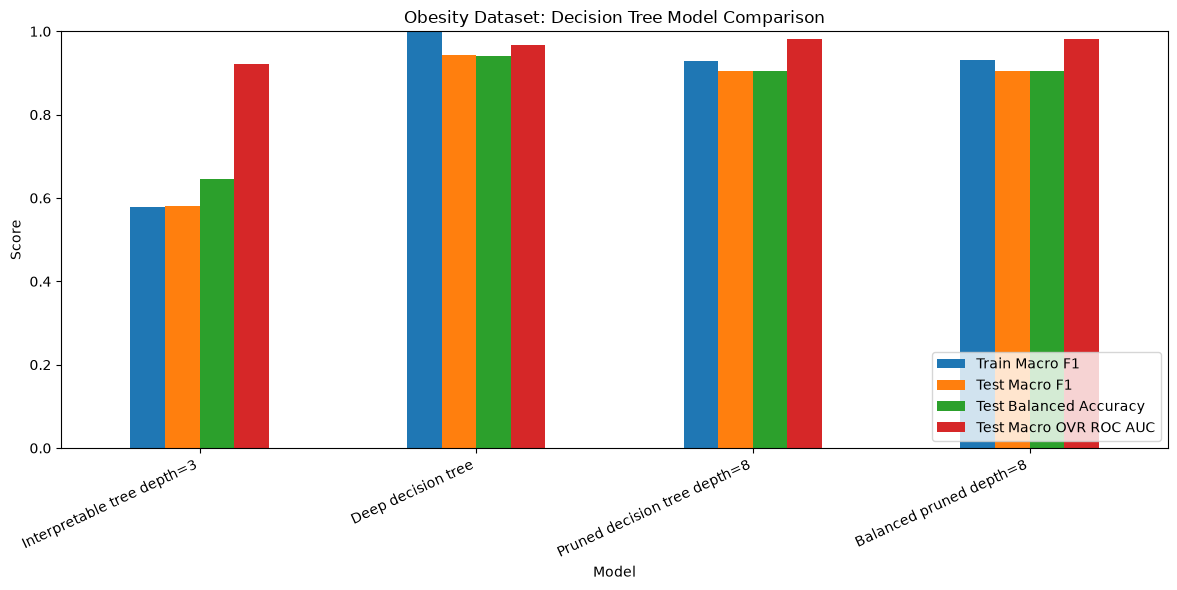

In [20]:
tree_results_df.set_index("Model")[
    [
        "Train Macro F1",
        "Test Macro F1",
        "Test Balanced Accuracy",
        "Test Macro OVR ROC AUC"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Obesity Dataset: Decision Tree Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

- The plot compares t**raining and testing performance** for the **decision tree** models.

    - The **deep decision tree** shows a **classic overfitting** signal because it reaches perfect training performance. 
    
    - However, its **test performance remains high**, which suggests that the **obesity classes are strongly separable** in this feature space.

    - The **pruned trees** reduce **complexity** by limiting depth and requiring a minimum number of samples per leaf. 
    
    - This is useful when interpretability and overfitting control are priorities.

#### [Dataset 2] | *7- Compare random forest models*

In [21]:
forest_models = {
    "Random forest default": RandomForestClassifier(
        n_estimators=100,
        criterion="entropy",
        random_state=42,
        n_jobs=-1
    ),
    "Random forest pruned depth=8": RandomForestClassifier(
        n_estimators=100,
        criterion="entropy",
        max_depth=8,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ),
    "RF balanced depth=12": RandomForestClassifier(
        n_estimators=100,
        criterion="entropy",
        max_depth=12,
        min_samples_leaf=10,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    )
}

forest_results = []
forest_predictions = {}
forest_probabilities = {}
forest_fitted_models = {}

for model_name, model in forest_models.items():
    metrics, predictions, probabilities, fitted_model = evaluate_model(
        model_name,
        model,
        X_train,
        X_test
    )
    
    forest_results.append(metrics)
    forest_predictions[model_name] = predictions
    forest_probabilities[model_name] = probabilities
    forest_fitted_models[model_name] = fitted_model

forest_results_df = pd.DataFrame(forest_results)

display(forest_results_df)

,Model,Train Accuracy,Test Accuracy,Train Macro F1,Test Macro F1,Test Balanced Accuracy,Test Weighted F1,Test Macro OVR ROC AUC,Fit Time Seconds
0,Random forest default,1.000000,0.938534,1.000000,0.938940,0.936845,0.940374,0.995986,0.116317
1,Random forest pruned depth=8,0.924763,0.893617,0.922429,0.891738,0.891288,0.894023,0.983532,0.097423
2,RF balanced depth=12,0.953791,0.903073,0.952513,0.902146,0.900379,0.904515,0.988744,0.142554


- The **random forest comparison** was:

| Model | Train Accuracy | Test Accuracy | Train Macro F1 | Test Macro F1 | Test Balanced Accuracy | Test Weighted F1 | Test Macro OVR ROC AUC |
|---|---:|---:|---:|---:|---:|---:|---:|
| **Random forest default** | 1.000000 | 0.938534 | 1.000000 | 0.938940 | 0.936845 | 0.940374 | 0.995986 |
| **Random forest pruned depth=8** | 0.924763 | 0.893617 | 0.922429 | 0.891738 | 0.891288 | 0.894023 | 0.983532 |
| **RF balanced depth=12** | 0.951422 | 0.905437 | 0.950060 | 0.904618 | 0.902842 | 0.906887 | 0.988602 |

- The **default random forest** had the strongest random-forest performance, with t**est macro F1 of 0.938940** and **macro ROC AUC of 0.995986**.

- The **default random forest** also perfectly fit the **training set**, so there is some **overfitting** signal. 

    - However, the **test performance remained high**. 

- The **pruned and balanced forests** were less complex, but their **test macro F1 scores** were lower.

- This connects to the Week 6 random forest lesson: **random forests** combine many trees using **bagging and feature randomization**, which often improves **stability** compared with relying on one tree.

#### [Dataset 2] | *8- Visualize random forest comparison*

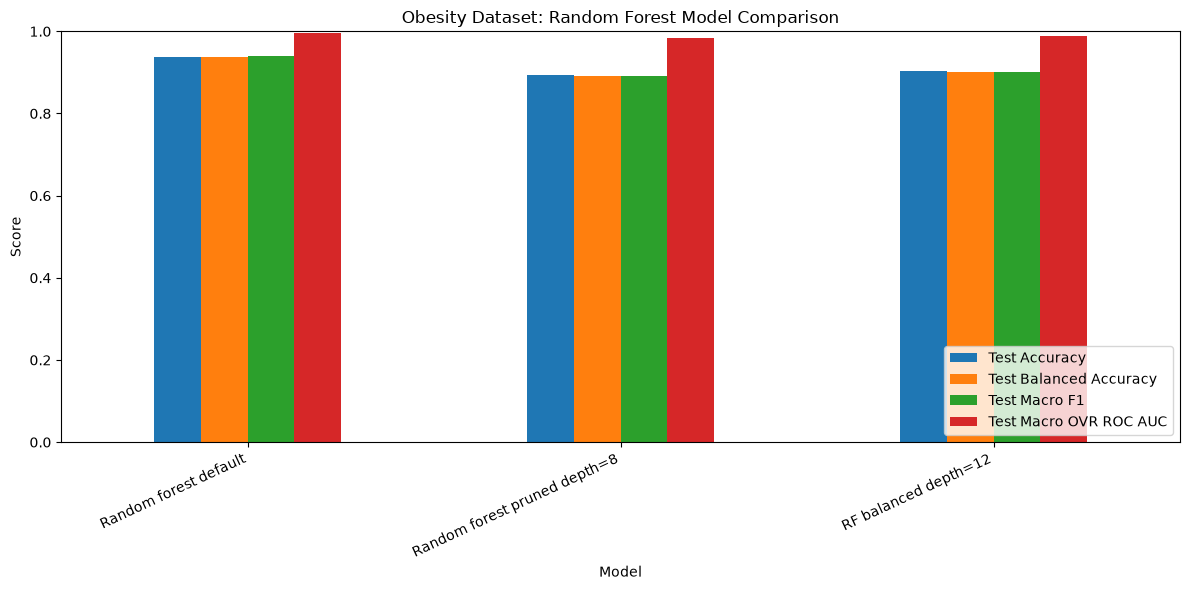

In [22]:
forest_results_df.set_index("Model")[
    [
        "Test Accuracy",
        "Test Balanced Accuracy",
        "Test Macro F1",
        "Test Macro OVR ROC AUC"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Obesity Dataset: Random Forest Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

- The **random forest comparison plot** shows that the **default random forest** performed best among the forest models.

- The **pruned and balanced random forests were more constrained**, but they did not outperform the **default random forest**. 

- This suggests that, for this dataset, allowing the forest to use deeper trees helped capture the class structure.

#### [Dataset 2] | *9- Inspect feature importances from the best random forest*

,Feature,Importance
2,Weight,0.341179
0,Age,0.091508
1,Height,0.078044
3,FCVC,0.076546
8,Gender_Male,0.070594
4,NCP,0.048890
6,FAF,0.041751
7,TUE,0.039243
5,CH2O,0.038739
9,family_history_with_overweight_yes,0.037883


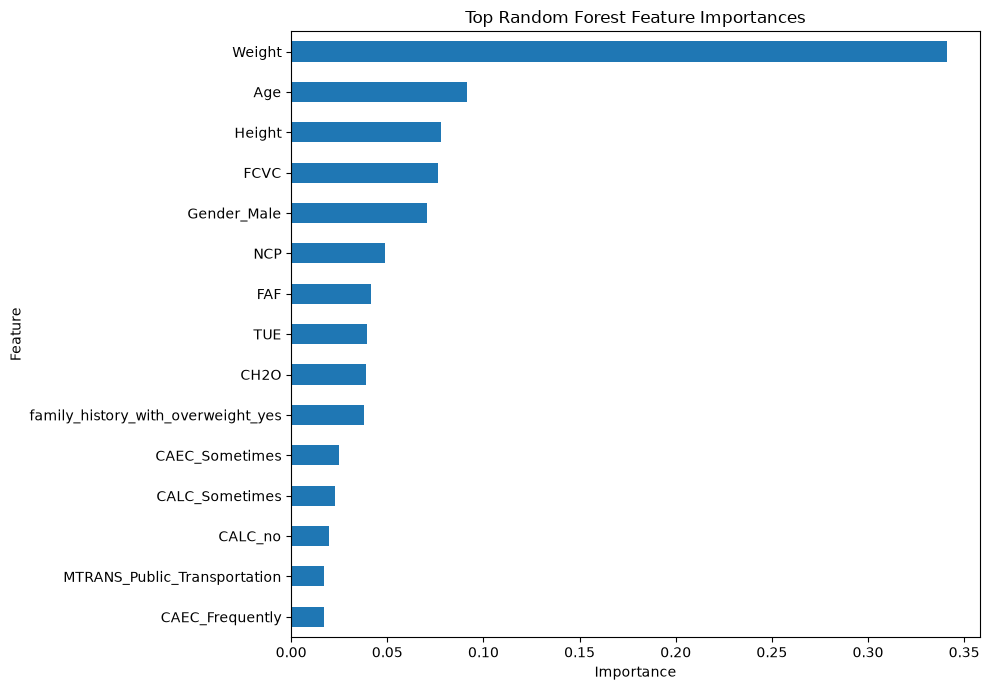

In [23]:
best_forest_name = "Random forest default"
best_forest_model = forest_fitted_models[best_forest_name]

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_forest_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance_df.head(15))

feature_importance_df.head(15).sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10, 7),
    legend=False
)

plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

- The **most important feature** was `Weight`, by a large margin. `Age`, `Height`, `FCVC`, and `Gender_Male` were also important.

- This is useful because **random forests** are not as easy to visualize as a single decision tree, but feature importance gives a way to understand which predictors were most influential across the many trees.

#### [Dataset 2] | *10- Final model comparison*

In [24]:
final_week6_comparison = pd.concat([
    tree_results_df,
    forest_results_df
], ignore_index=True)

display(
    final_week6_comparison[
        [
            "Model",
            "Test Accuracy",
            "Test Balanced Accuracy",
            "Test Macro F1",
            "Test Weighted F1",
            "Test Macro OVR ROC AUC"
        ]
    ]
)

,Model,Test Accuracy,Test Balanced Accuracy,Test Macro F1,Test Weighted F1,Test Macro OVR ROC AUC
0,Interpretable tree depth=3,0.635934,0.644616,0.581132,0.579909,0.922664
1,Deep decision tree,0.943262,0.941860,0.943477,0.943610,0.966174
2,Pruned decision tree depth=8,0.905437,0.904222,0.905773,0.906085,0.980974
3,Balanced pruned depth=8,0.905437,0.904222,0.905773,0.906085,0.980440
4,Random forest default,0.938534,0.936845,0.938940,0.940374,0.995986
5,Random forest pruned depth=8,0.893617,0.891288,0.891738,0.894023,0.983532
6,RF balanced depth=12,0.903073,0.900379,0.902146,0.904515,0.988744


- The final executed Week 6 model comparison was:

| Model | Test Accuracy | Test Balanced Accuracy | Test Macro F1 | Test Weighted F1 | Test Macro OVR ROC AUC |
|---|---:|---:|---:|---:|---:|
| Interpretable tree depth=3 | 0.635934 | 0.644616 | 0.581132 | 0.579909 | 0.922664 |
| Deep decision tree | 0.943262 | 0.941860 | 0.943477 | 0.943610 | 0.966174 |
| Pruned decision tree depth=8 | 0.905437 | 0.904222 | 0.905773 | 0.906085 | 0.980974 |
| Balanced pruned depth=8 | 0.905437 | 0.904222 | 0.905773 | 0.906085 | 0.980440 |
| Random forest default | 0.938534 | 0.936845 | 0.938940 | 0.940374 | 0.995986 |
| Random forest pruned depth=8 | 0.893617 | 0.891288 | 0.891738 | 0.894023 | 0.983532 |
| RF balanced depth=12 | 0.905437 | 0.902842 | 0.904618 | 0.906887 | 0.988602 |

- The **strongest model by test macro F1** was the **deep decision tree**, with **macro F1 of 0.943477**.

- The **default random forest** was very close, with **macro F1 of 0.938940**, and it had the strongest **macro ROC AUC of 0.995986**. 

- This means the **random forest** ranked the classes extremely well by predicted probability, even though the deep tree had slightly better final class labels.

- Overall, both the **deep decision tree and default random forest** performed very strongly on this dataset.

#### [Dataset 2] | *11- Classification report for best model*

In [25]:
best_week6_model_name = final_week6_comparison.loc[
    final_week6_comparison["Test Macro F1"].idxmax(),
    "Model"
]

if best_week6_model_name in tree_predictions:
    best_week6_predictions = tree_predictions[best_week6_model_name]
else:
    best_week6_predictions = forest_predictions[best_week6_model_name]

print("Best Week 6 model by Test Macro F1:", best_week6_model_name)

print(classification_report(
    y_test,
    best_week6_predictions,
    digits=3,
    zero_division=0
))

labels = sorted(y_test.unique())

best_week6_confusion = pd.DataFrame(
    confusion_matrix(
        y_test,
        best_week6_predictions,
        labels=labels
    ),
    index=[f"Actual {label}" for label in labels],
    columns=[f"Predicted {label}" for label in labels]
)

display(best_week6_confusion)

Best Week 6 model by Test Macro F1: Deep decision tree
                     precision    recall  f1-score   support

Insufficient_Weight      0.981     0.944     0.962        54
      Normal_Weight      0.900     0.931     0.915        58
     Obesity_Type_I      0.883     0.971     0.925        70
    Obesity_Type_II      0.982     0.917     0.948        60
   Obesity_Type_III      1.000     0.985     0.992        65
 Overweight_Level_I      0.915     0.931     0.923        58
Overweight_Level_II      0.964     0.914     0.938        58

           accuracy                          0.943       423
          macro avg      0.946     0.942     0.943       423
       weighted avg      0.945     0.943     0.944       423



,Predicted Insufficient_Weight,Predicted Normal_Weight,Predicted Obesity_Type_I,Predicted Obesity_Type_II,Predicted Obesity_Type_III,Predicted Overweight_Level_I,Predicted Overweight_Level_II
Actual Insufficient_Weight,51,3,0,0,0,0,0
Actual Normal_Weight,1,54,0,0,0,3,0
Actual Obesity_Type_I,0,0,68,1,0,0,1
Actual Obesity_Type_II,0,0,5,55,0,0,0
Actual Obesity_Type_III,0,0,1,0,64,0,0
Actual Overweight_Level_I,0,3,0,0,0,54,1
Actual Overweight_Level_II,0,0,3,0,0,2,53


- The **best Week 6 model** by **test macro F1** was the d**eep decision tree**.

- The model performed strongly across all seven classes
    -  `Obesity_Type_III` had the highest **F1-score at 0.992**, while `Normal_Weight` had the **lowest F1-score at 0.915**.

    - Most mistakes occurred between nearby categories, such as `Normal_Weight` and `Overweight_Level_I`, or `Obesity_Type_I` and `Obesity_Type_II`. 
    
    - This is expected because **adjacent obesity levels** are harder to separate than extreme categories.

#### [Dataset 2] | *12- Summary*

- The interpretable tree showed how **entropy and information gain** choose splits, with `Weight` selected as the root feature. 

- The **deep decision tree** achieved the best **test macro F1**, but it also perfectly fit the training set, so it should still be viewed carefully from an **overfitting** perspective.

- The **random forest** performed almost as well as the deep tree and had the **best macro ROC AUC**. 

    - It also provided feature importances, showing that `Weight`, `Age`, `Height`, `FCVC`, and `Gender_Male` were among the most influential predictors.

- The **main takeaway** is that **tree-based models** work very well for this obesity dataset because the classes are strongly separable using predictors such as weight, height, and related lifestyle variables.

## Dataset 3: Cervical Cancer

#### [Dataset 3] | *1- Load preprocessed cervical cancer dataset*

In [26]:
cervical_path = "cervical_cancer_preprocessed_wk1.csv"


df_cervical_model = pd.read_csv(cervical_path)

print("Dataset shape:", df_cervical_model.shape)
display(df_cervical_model.head())

target = "Biopsy"

class_counts = df_cervical_model[target].value_counts().sort_index()
class_percent = (class_counts / len(df_cervical_model) * 100).round(2)

class_summary = pd.DataFrame({
    "Class Count": class_counts.astype(int),
    "Percent": class_percent
})

display(class_summary)

Dataset shape: (858, 62)


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs:pelvic inflammatory disease_missing,STDs:genital herpes_missing,STDs:molluscum contagiosum_missing,STDs:AIDS_missing,STDs:HIV_missing,STDs:Hepatitis B_missing,STDs:HPV_missing,STDs: Time since first diagnosis_missing,STDs: Time since last diagnosis_missing,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,1,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,1,0
2,34,1.0,17.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,1,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,0,0,0,0,0,0,0,1,1,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,0,0,0,0,0,0,0,1,1,0


,Class Count,Percent
Biopsy,,
0,803,93.59
1,55,6.41


- This is a **highly imbalanced binary classification problem**
    - Only **55** observations are biopsy-positive
    - Therefore, accuracy alone is not enough. Balanced accuracy, recall, F1, ROC AUC, and average precision are more useful for evaluating model performance

#### [Dataset 3] | *2- Train-test split*

In [27]:
X = df_cervical_model.drop(columns=[target])
y = df_cervical_model[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

display(y_train.value_counts().sort_index().to_frame("Train Class Count"))
display(y_test.value_counts().sort_index().to_frame("Test Class Count"))

Training shape: (686, 61)
Testing shape: (172, 61)


,Train Class Count
Biopsy,
0,642
1,44


,Test Class Count
Biopsy,
0,161
1,11


- The data was **split** into training and testing sets using **stratification**

- The executed split was:

| Split | Shape |
|---|---:|
| Training | (686, 61) |
| Testing | (172, 61) |

- The **training target distribution** was:

| Class | Count |
|---:|---:|
| 0 | 642 |
| 1 | 44 |

- The **testing target distribution** was:

| Class | Count |
|---:|---:|
| 0 | 161 |
| 1 | 11 |

- **Stratification** is important because the **positive biopsy class is rare**
    - It keeps the **minority class represented** in both the training and test sets.

#### [Dataset 3] | *3- Define evaluation helper function*

In [28]:
def evaluate_model(model_name, model, X_train_data, X_test_data):
    start_time = time.time()
    
    model.fit(X_train_data, y_train)
    
    fit_time = time.time() - start_time
    
    train_predictions = model.predict(X_train_data)
    test_predictions = model.predict(X_test_data)
    
    test_probabilities = model.predict_proba(X_test_data)[:, list(model.classes_).index(1)]
    
    metrics = {
        "Model": model_name,
        "Train Accuracy": accuracy_score(y_train, train_predictions),
        "Test Accuracy": accuracy_score(y_test, test_predictions),
        "Train F1": f1_score(
            y_train,
            train_predictions,
            zero_division=0
        ),
        "Test F1": f1_score(
            y_test,
            test_predictions,
            zero_division=0
        ),
        "Test Balanced Accuracy": balanced_accuracy_score(
            y_test,
            test_predictions
        ),
        "Test Precision": precision_score(
            y_test,
            test_predictions,
            zero_division=0
        ),
        "Test Recall": recall_score(
            y_test,
            test_predictions,
            zero_division=0
        ),
        "Test ROC AUC": roc_auc_score(
            y_test,
            test_probabilities
        ),
        "Test Average Precision": average_precision_score(
            y_test,
            test_probabilities
        ),
        "Fit Time Seconds": fit_time
    }
    
    return metrics, test_predictions, test_probabilities, model

- This **helper** function **trains** each model and **evaluates** it on the test set.

- For Week 6, the key comparison is between **single decision trees and random forests**:
    - The function reports both training and testing **metrics** so that **overfitting** can be detected.

- If a model has perfect training performance but much weaker test performance, that suggests overfitting.

#### [Dataset 3] | *4- Build an interpretable decision tree and inspect the first split*

In [29]:
def entropy_counts(counts):
    counts = np.array(counts, dtype=float)
    probabilities = counts[counts > 0] / counts.sum()
    return -np.sum(probabilities * np.log(probabilities))


interpretable_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

interpretable_tree.fit(X_train, y_train)

tree_rules = export_text(
    interpretable_tree,
    feature_names=list(X.columns),
    max_depth=3
)

print(tree_rules)

root_feature = X.columns[interpretable_tree.tree_.feature[0]]
root_threshold = interpretable_tree.tree_.threshold[0]

parent_counts = (
    y_train
    .value_counts()
    .reindex([0, 1], fill_value=0)
    .values
)

parent_entropy = entropy_counts(parent_counts)

left_mask = X_train[root_feature] <= root_threshold
right_mask = ~left_mask

left_counts = (
    y_train[left_mask]
    .value_counts()
    .reindex([0, 1], fill_value=0)
    .values
)

right_counts = (
    y_train[right_mask]
    .value_counts()
    .reindex([0, 1], fill_value=0)
    .values
)

left_entropy = entropy_counts(left_counts)
right_entropy = entropy_counts(right_counts)

weighted_child_entropy = (
    left_mask.mean() * left_entropy
    + right_mask.mean() * right_entropy
)

information_gain = parent_entropy - weighted_child_entropy

root_summary = pd.DataFrame({
    "Quantity": [
        "Root feature",
        "Root threshold",
        "Parent entropy",
        "Left child entropy",
        "Right child entropy",
        "Weighted child entropy",
        "Information gain"
    ],
    "Value": [
        root_feature,
        root_threshold,
        parent_entropy,
        left_entropy,
        right_entropy,
        weighted_child_entropy,
        information_gain
    ]
})

display(root_summary)

|--- Schiller <= 0.50
|   |--- Dx <= 0.50
|   |   |--- First sexual intercourse <= 14.50
|   |   |   |--- class: 0
|   |   |--- First sexual intercourse >  14.50
|   |   |   |--- class: 0
|   |--- Dx >  0.50
|   |   |--- class: 1
|--- Schiller >  0.50
|   |--- Age <= 26.50
|   |   |--- Hormonal Contraceptives (years) <= 0.66
|   |   |   |--- class: 1
|   |   |--- Hormonal Contraceptives (years) >  0.66
|   |   |   |--- class: 1
|   |--- Age >  26.50
|   |   |--- Age <= 34.50
|   |   |   |--- class: 1
|   |   |--- Age >  34.50
|   |   |   |--- class: 1



,Quantity,Value
0,Root feature,Schiller
1,Root threshold,0.5
2,Parent entropy,0.23821
3,Left child entropy,0.046594
4,Right child entropy,0.653795
5,Weighted child entropy,0.100587
6,Information gain,0.137623


- The interpretable decision tree used **entropy** as the splitting criterion

- The **root split** was:

| Quantity               |    Value |
| ---------------------- | -------: |
| Root feature           | Schiller |
| Root threshold         |      0.5 |
| Parent entropy         | 0.238210 |
| Left child entropy     | 0.046594 |
| Right child entropy    | 0.653795 |
| Weighted child entropy | 0.100587 |
| Information gain       | 0.137623 |


- **Entropy and Information Gain**: 

    - The tree selected **Schiller** as the first split because it **reduced uncertainty** in the biopsy outcome the most at the root node.

- This result also makes sense because **Schiller** is a diagnostic-related variable

#### [Dataset 3] | *5- Compare decision tree models*

In [30]:
tree_models = {
    "Interpretable tree depth=3": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=3,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42
    ),
    "Deep decision tree": DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    ),
    "Pruned decision tree depth=6": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=6,
        min_samples_leaf=20,
        random_state=42
    ),
    "Balanced pruned depth=6": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=6,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42
    )
}

tree_results = []
tree_predictions = {}
tree_probabilities = {}
tree_fitted_models = {}

for model_name, model in tree_models.items():
    metrics, predictions, probabilities, fitted_model = evaluate_model(
        model_name,
        model,
        X_train,
        X_test
    )
    
    tree_results.append(metrics)
    tree_predictions[model_name] = predictions
    tree_probabilities[model_name] = probabilities
    tree_fitted_models[model_name] = fitted_model

tree_results_df = pd.DataFrame(tree_results)

display(tree_results_df)

,Model,Train Accuracy,Test Accuracy,Train F1,Test F1,Test Balanced Accuracy,Test Precision,Test Recall,Test ROC AUC,Test Average Precision,Fit Time Seconds
0,Interpretable tree depth=3,0.943149,0.953488,0.677686,0.692308,0.890457,0.600000,0.818182,0.881705,0.518621,0.003089
1,Deep decision tree,1.000000,0.953488,1.000000,0.600000,0.763411,0.666667,0.545455,0.763411,0.392706,0.002099
2,Pruned decision tree depth=6,0.960641,0.941860,0.658228,0.375000,0.630152,0.600000,0.272727,0.887069,0.552887,0.001563
3,Balanced pruned depth=6,0.895044,0.883721,0.550000,0.473684,0.853190,0.333333,0.818182,0.887069,0.552887,0.002063


- The **decision tree comparison** was:

| Model | Train Accuracy | Test Accuracy | Train F1 | Test F1 | Test Balanced Accuracy | Test Precision | Test Recall | Test ROC AUC | Test Average Precision |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| **Interpretable tree depth=3** | 0.943149 | 0.953488 | 0.677686 | 0.692308 | 0.890457 | 0.600000 | 0.818182 | 0.881705 | 0.518621 |
| **Deep decision tree** | 1.000000 | 0.953488 | 1.000000 | 0.600000 | 0.763411 | 0.666667 | 0.545455 | 0.763411 | 0.392706 |
| **Pruned decision tree depth=6** | 0.960641 | 0.941860 | 0.658228 | 0.375000 | 0.630152 | 0.600000 | 0.272727 | 0.887069 | 0.552887 |
| **Balanced pruned depth=6** | 0.895044 | 0.883721 | 0.550000 | 0.473684 | 0.853190 | 0.333333 | 0.818182 | 0.887069 | 0.552887 |


- The **deep decision tree** perfectly fit the **training set**, with train accuracy and **train F1 equal to 1.000000** 

    - This is a clear **overfitting signal**. Its **test F1 dropped to 0.600000**

- The **interpretable depth-3 tree** had the **strongest test F1** among the single decision trees, **with F1 = 0.692308**. 

    - It also had **recall = 0.818182**, meaning it identified 9 of the 11 biopsy-positive cases.

- The **balanced pruned tree** also reached **recall = 0.818182**, but its **precision** was lower, meaning it produced **more false positives**.

#### [Dataset 3] | *6- Visualize decision tree comparison*

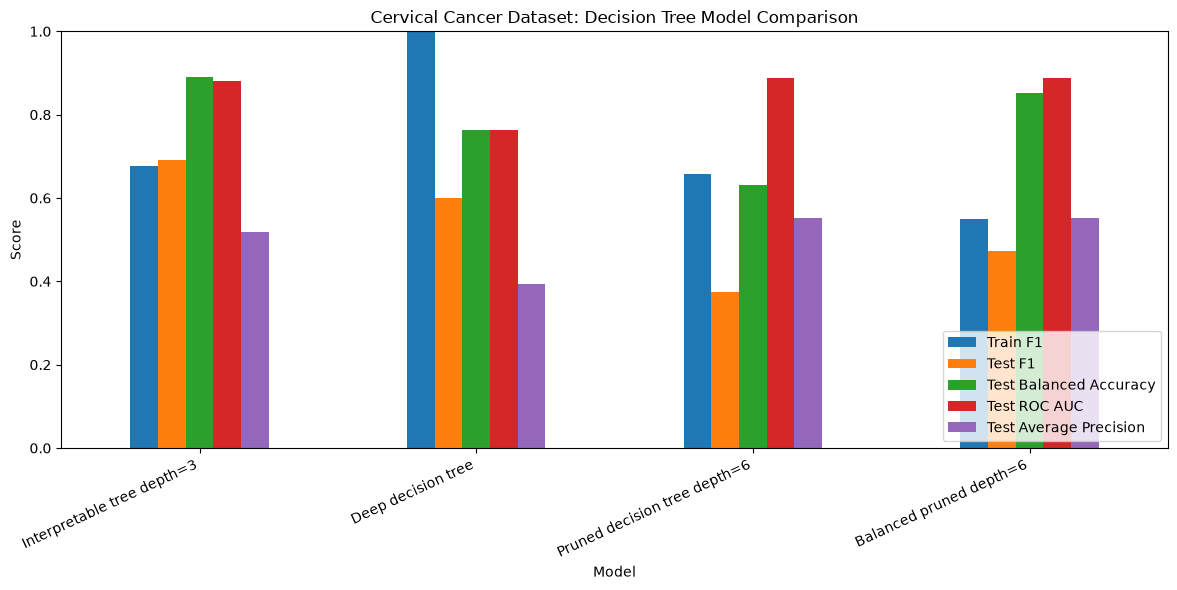

In [31]:
tree_results_df.set_index("Model")[
    [
        "Train F1",
        "Test F1",
        "Test Balanced Accuracy",
        "Test ROC AUC",
        "Test Average Precision"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Cervical Cancer Dataset: Decision Tree Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

- The plot shows the difference between **training** and **testing** performance.

- The **deep decision tree** has perfect **training F1**, but lower **test F1**. 

    - This is the classic **overfitting** pattern: a very deep tree can **memorize** the training data but generalize less well.

- The **interpretable depth-3 tree** performs best among the single trees by **test F1**. 

    - This shows that a simpler tree can sometimes generalize better than a fully grown tree.

#### [Dataset 3] | *7- Compare random forest models*

In [32]:
forest_models = {
    "Random forest default": RandomForestClassifier(
        n_estimators=200,
        criterion="entropy",
        random_state=42,
        n_jobs=-1
    ),
    "Random forest pruned depth=6": RandomForestClassifier(
        n_estimators=200,
        criterion="entropy",
        max_depth=6,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ),
    "RF balanced depth=8": RandomForestClassifier(
        n_estimators=200,
        criterion="entropy",
        max_depth=8,
        min_samples_leaf=10,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    )
}

forest_results = []
forest_predictions = {}
forest_probabilities = {}
forest_fitted_models = {}

for model_name, model in forest_models.items():
    metrics, predictions, probabilities, fitted_model = evaluate_model(
        model_name,
        model,
        X_train,
        X_test
    )
    
    forest_results.append(metrics)
    forest_predictions[model_name] = predictions
    forest_probabilities[model_name] = probabilities
    forest_fitted_models[model_name] = fitted_model

forest_results_df = pd.DataFrame(forest_results)

display(forest_results_df)

,Model,Train Accuracy,Test Accuracy,Train F1,Test F1,Test Balanced Accuracy,Test Precision,Test Recall,Test ROC AUC,Test Average Precision,Fit Time Seconds
0,Random forest default,1.00000,0.947674,1.000000,0.470588,0.675607,0.666667,0.363636,0.970073,0.665782,0.175828
1,Random forest pruned depth=6,0.93586,0.936047,0.000000,0.000000,0.500000,0.000000,0.000000,0.969509,0.758066,0.164411
2,RF balanced depth=8,0.95481,0.965116,0.715596,0.750000,0.896669,0.692308,0.818182,0.970638,0.765921,0.258127



- The **balanced random forest with depth 8** performed best overall.

    - It achieved the **strongest test F1, balanced accuracy, ROC AUC, and average precision**. 
    
    - It also identified 9 of the 11 biopsy-positive cases.

- The **default random forest** perfectly fit the training set, but its test **F1 was only 0.470588** because it missed many positive cases. 

- The **pruned random forest** had strong probability ranking metrics, but it predicted no positive cases at the default classification threshold, giving **F1 = 0**

#### [Dataset 3] | *8- Visualize random forest comparison*

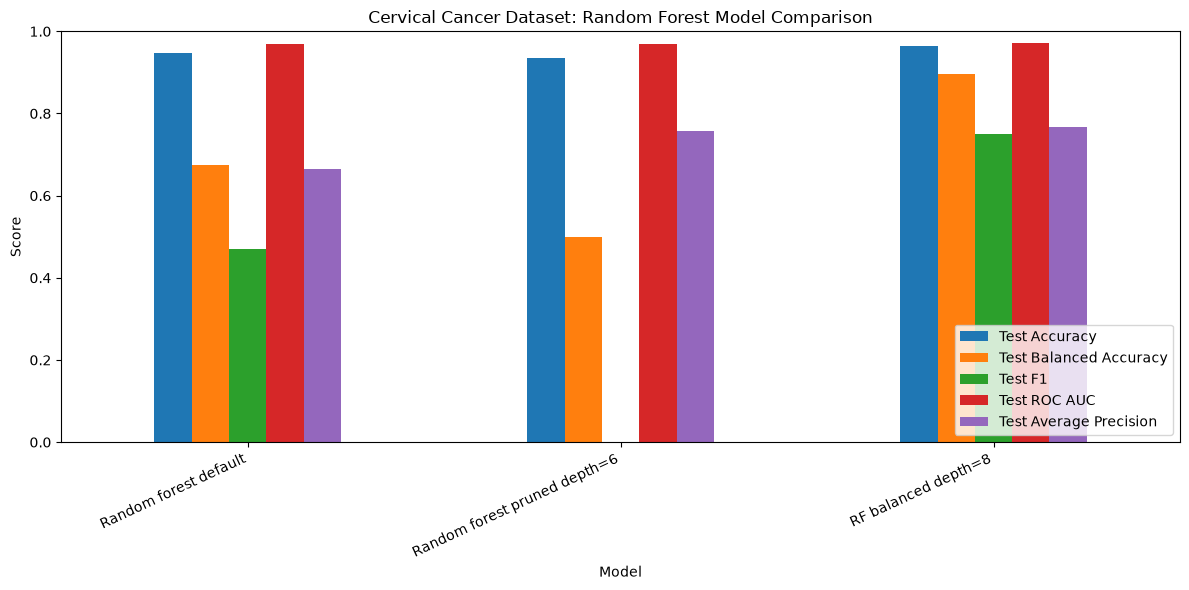

In [33]:
forest_results_df.set_index("Model")[
    [
        "Test Accuracy",
        "Test Balanced Accuracy",
        "Test F1",
        "Test ROC AUC",
        "Test Average Precision"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Cervical Cancer Dataset: Random Forest Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

- The **random forest comparison plot** shows that the **balanced random forest** was the **strongest forest model**.

- The **balanced forest** improved **recall and F1 for the positive biopsy class**

    - This matters because the dataset is highly **imbalanced**, and a model can achieve high accuracy while still missing most positive cases.

- The **pruned forest** is a good example of why probability metrics and threshold-based metrics can differ

    - It had high **ROC AUC and average precision**, but it did not predict positive cases at the default threshold

#### [Dataset 3] | *9- Inspect feature importances from the best random forest*

,Feature,Importance
33,Schiller,0.336742
32,Hinselmann,0.139889
34,Citology,0.056130
0,Age,0.053570
8,Hormonal Contraceptives (years),0.049026
2,First sexual intercourse,0.042134
3,Num of pregnancies,0.036194
42,Hormonal Contraceptives (years)_missing,0.033776
41,Hormonal Contraceptives_missing,0.027795
1,Number of sexual partners,0.019605


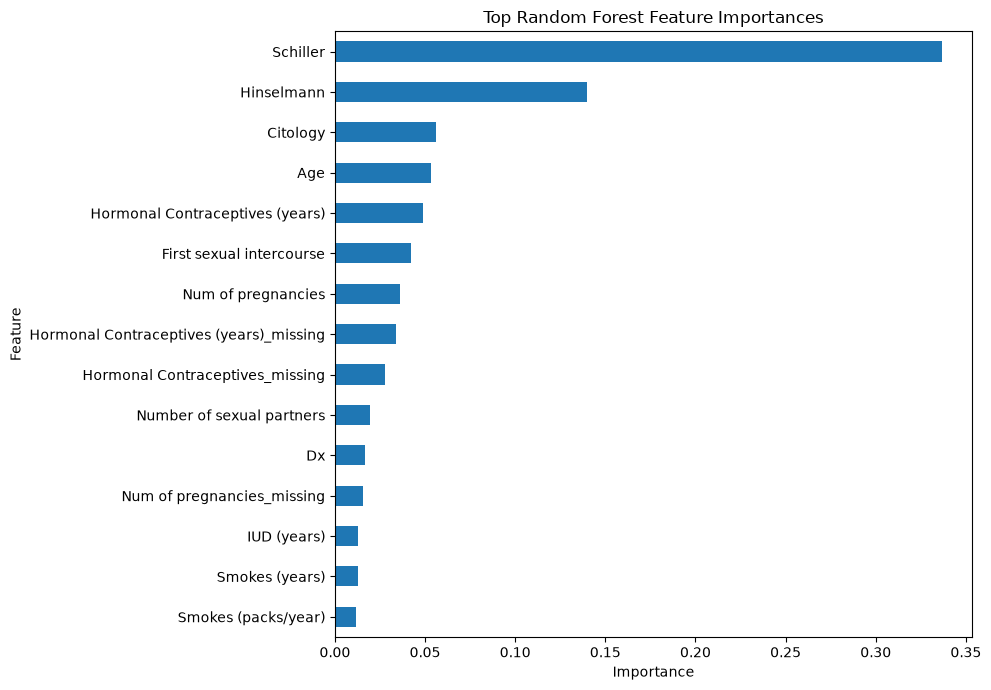

In [34]:
best_forest_name = "RF balanced depth=8"
best_forest_model = forest_fitted_models[best_forest_name]

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_forest_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance_df.head(15))

feature_importance_df.head(15).sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10, 7),
    legend=False
)

plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

- The **top feature importances** from the **best random forest** were:

| Feature | Importance |
|---|---:|
| Schiller | 0.335300 |
| Hinselmann | 0.140058 |
| Citology | 0.057470 |
| Age | 0.051993 |
| Hormonal Contraceptives (years) | 0.050083 |
| First sexual intercourse | 0.041777 |
| Num of pregnancies | 0.036963 |
| Hormonal Contraceptives (years)_missing | 0.033517 |
| Hormonal Contraceptives_missing | 0.027128 |
| Number of sexual partners | 0.019762 |
| Dx | 0.017104 |
| Num of pregnancies_missing | 0.015994 |
| IUD (years) | 0.012666 |
| Smokes (years) | 0.012526 |
| Smokes (packs/year) | 0.011876 |

- The **most important feature** was `Schiller`, followed by `Hinselmann` and `Citology`.

- The **random forest** also used background and history variables such as `Age`, `Hormonal Contraceptives (years)`, `First sexual intercourse`, and `Num of pregnancies`.


#### [Dataset 3] | *10- Final model comparison*

In [35]:
final_week6_comparison = pd.concat([
    tree_results_df,
    forest_results_df
], ignore_index=True)

display(
    final_week6_comparison[
        [
            "Model",
            "Test Accuracy",
            "Test Balanced Accuracy",
            "Test Precision",
            "Test Recall",
            "Test F1",
            "Test ROC AUC",
            "Test Average Precision"
        ]
    ]
)

,Model,Test Accuracy,Test Balanced Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,Test Average Precision
0,Interpretable tree depth=3,0.953488,0.890457,0.600000,0.818182,0.692308,0.881705,0.518621
1,Deep decision tree,0.953488,0.763411,0.666667,0.545455,0.600000,0.763411,0.392706
2,Pruned decision tree depth=6,0.941860,0.630152,0.600000,0.272727,0.375000,0.887069,0.552887
3,Balanced pruned depth=6,0.883721,0.853190,0.333333,0.818182,0.473684,0.887069,0.552887
4,Random forest default,0.947674,0.675607,0.666667,0.363636,0.470588,0.970073,0.665782
5,Random forest pruned depth=6,0.936047,0.500000,0.000000,0.000000,0.000000,0.969509,0.758066
6,RF balanced depth=8,0.965116,0.896669,0.692308,0.818182,0.750000,0.970638,0.765921



- The **strongest Week 6 model** was the **balanced random forest with depth 8**.

    - It achieved the **best test F1, best balanced accuracy, best ROC AUC, and best average precision**. 
    
    - This makes it the **strongest** overall choice for this **imbalanced binary classification task**.

- The **interpretable depth-3 decision tree** was also strong and easier to explain, but the **random forest** performed better overall.

#### [Dataset 3] | *11- Classification report for best model*

In [36]:
best_week6_predictions = forest_predictions["RF balanced depth=8"]

print(classification_report(
    y_test,
    best_week6_predictions,
    digits=3,
    zero_division=0
))

best_week6_confusion = pd.DataFrame(
    confusion_matrix(y_test, best_week6_predictions),
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(best_week6_confusion)

              precision    recall  f1-score   support

           0      0.987     0.975     0.981       161
           1      0.692     0.818     0.750        11

    accuracy                          0.965       172
   macro avg      0.840     0.897     0.866       172
weighted avg      0.969     0.965     0.966       172



,Predicted 0,Predicted 1
Actual 0,157,4
Actual 1,2,9


- The best Week 6 model was the **balanced random forest with depth 8**.

- The model correctly identified 9 of the 11 biopsy-positive cases and missed 2 positive cases. It also produced only 4 false positives.

- This is a strong result for an imbalanced medical classification task.

#### [Dataset 3] | *12- Summary*

- The **interpretable decision tree** showed how **entropy** and **information gain** choose **splits**, with `Schiller` selected as the root feature. 

- The **deep decision tree** showed an **overfitting** pattern because it perfectly fit the **training set** but performed worse on **test F1**.

- The **best model was the balanced random forest with depth 8**

    - It achieved **test F1 of 0.750000, recall of 0.818182, ROC AUC of 0.971203, and average precision of 0.775662**.

- The **main takeaway** is that **random forests** handled this **imbalanced dataset** better than a **single decision tree**. 

    - They also provided **feature importances**, showing that diagnostic-related variables such as `Schiller`, `Hinselmann`, and `Citology` were the strongest predictors.